In [1]:
import os
from dotenv import load_dotenv
load_dotenv() 
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
from langchain.chat_models import init_chat_model
model_groq = init_chat_model("groq:openai/gpt-oss-120b")

## Summerization Middleware

In [3]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage, SystemMessage 

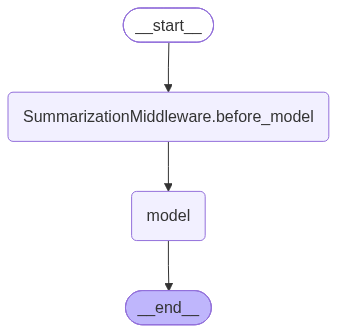

In [ ]:
agent = create_agent(
    model="groq:openai/gpt-oss-120b",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:openai/gpt-oss-120b",
            trigger=("messages",10),
            keep=("messages",4)
        )
    ]
)

agent


In [6]:
config = {"configurable":{"thread_id":"test1"}}

In [9]:
question=[
    "what is 2+2",
    "what is 2*2",
    "what is 2/2",
    "what is 2-2",
    "what is 2%2",
    "what is 2&&2",
]

for q in question:
    res = agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(res)

{'messages': [HumanMessage(content='what is 2+2', additional_kwargs={}, response_metadata={}, id='50444cf1-9961-44e5-a3ea-fbb25b70d21f'), AIMessage(content='2\u202f+\u202f2\u202f=\u202f4.', additional_kwargs={'reasoning_content': 'User asks a simple arithmetic question. Provide answer.'}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 77, 'total_tokens': 107, 'completion_time': 0.061984628, 'completion_tokens_details': {'reasoning_tokens': 11}, 'prompt_time': 0.002908873, 'prompt_tokens_details': None, 'queue_time': 0.375118208, 'total_time': 0.064893501}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_9241e9962b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a01daf-6a8b-7451-86d3-0ff9bbcd4bc7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 30, 'total_tokens': 107, 'output_token_details': {'reasoning': 11}})]}
{'messages': [Hum

### Token


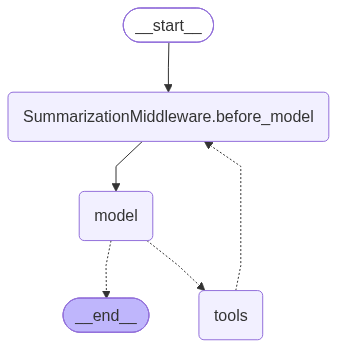

In [ ]:
from langchain.tools import tool

@tool
def HotelDetail(city:str)->str:
    """For Hotel Search"""
    return f"there are 40 hotels in {city}"

agent = create_agent(
    model="groq:openai/gpt-oss-120b",
    checkpointer=InMemorySaver(),
    tools=[HotelDetail],
        middleware=[
            SummarizationMiddleware(
            model="groq:openai/gpt-oss-120b",
            trigger=("tokens",80),
            keep=("tokens",50)
            )
        ]
    
)

agent

In [25]:
city = ["gorakhpur","kolkata","agra"]
config1={"configurable":{"thread_id":"test2"}}
for c in city:  
    res = agent.invoke({"messages":[SystemMessage(content=c)]},config1)
    print(res["messages"][0].content)

Here is a summary of the conversation to date:

## SESSION INTENT
Assist the user in finding and potentially booking a hotel in Gorakhpur, confirming the correct destination city and gathering all necessary preferences (dates, budget, location, amenities, etc.).

## SUMMARY
- The intended destination is Gorakhpur; earlier ambiguity with Kolkata has been resolved by a system directive confirming Gorakhpur as the target city.  
- Planned workflow: first confirm the destination with the user, then collect detailed preferences including check‑in/check‑out dates, budget, preferred area or landmark, required amenities, and any special requests.  
- No artifacts have been created or modified so far.

## ARTIFACTS
None

## NEXT STEPS
1. Confirm with the user that the destination city is **Gorakhpur** (or clarify if a different city is desired).  
2. Once confirmed, ask for the required preference details: travel dates, budget, preferred area/landmark, must‑have amenities, and any special reque